<a href="https://colab.research.google.com/github/MLevkovets/TensorflowVSPyTorch/blob/main/TensorflowVSPyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In this notebook I want to compare building a simple CNN with Tensorflow  Keras and PyTorch

## Data loading and pre-processing (Tensorflow)

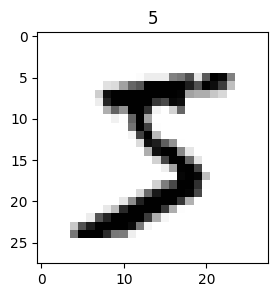

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the digits dataset
(X_train, y_train), (X_valid, y_valid) = mnist.load_data()

# Display the last digit
plt.figure(1, figsize=(3, 3))
plt.imshow(X_train[0], cmap=plt.cm.gray_r, interpolation="nearest")
plt.title(y_train[0])
plt.show()

In [ ]:
print(X_train.max())

255


### Normalization

In [11]:
X_train, X_valid = X_train/255, X_valid /255

## Buinding a CNN with Tensorfow

In [12]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3),
                        activation = 'relu',
                        input_shape = (28,28,1),
                        padding = 'same',
                        kernel_initializer='he_normal',
                        bias_initializer = 'zeros'))
#model.add(layers.MaxPooling2D())
model.add(layers.Dropout(0.15))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu',
                       kernel_initializer='he_normal',
                       bias_initializer = 'zeros'))
model.add(layers.Dense(10, activation = 'softmax'))
model.summary()
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, batch_size = 512,
                    validation_data=(X_valid, y_valid))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       802,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,498 (3.07 MB)

 Trainable params: 803,498 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 45s 374ms/step - accuracy: 0.9138 - loss: 0.2880 - val_accuracy: 0.9610 - val_loss: 0.1283
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 81s 367ms/step - accuracy: 0.9713 - loss: 0.0995 - val_accuracy: 0.9736 - val_loss: 0.0847
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 87s 414ms/step - accuracy: 0.9818 - loss: 0.0629 - val_accuracy: 0.9794 - val_loss: 0.0676
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 79s 388ms/step - accuracy: 0.9871 - loss: 0.0448 - val_accuracy: 0.9798 - val_loss: 0.0642
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 44s 372ms/step - accuracy: 0.9909 - loss: 0.0321 - val_accuracy: 0.9824 - val_loss: 0.0576
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 372ms/step - accuracy: 0.9935 - loss: 0.0241 - val_accuracy: 0.9823 - val_loss: 0.0575
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 44s 372ms/step - accuracy: 0.9954 - loss: 0.0184 - val_accuracy: 0.9816 - val_loss: 0.0550
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 43s 366ms/step - accuracy: 0.9960 - loss: 0

## Results of the training

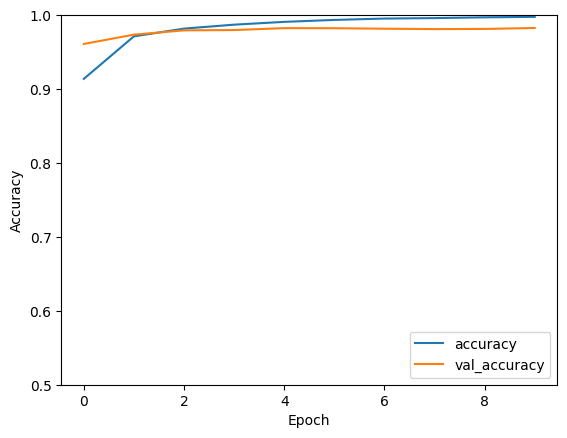

In [13]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


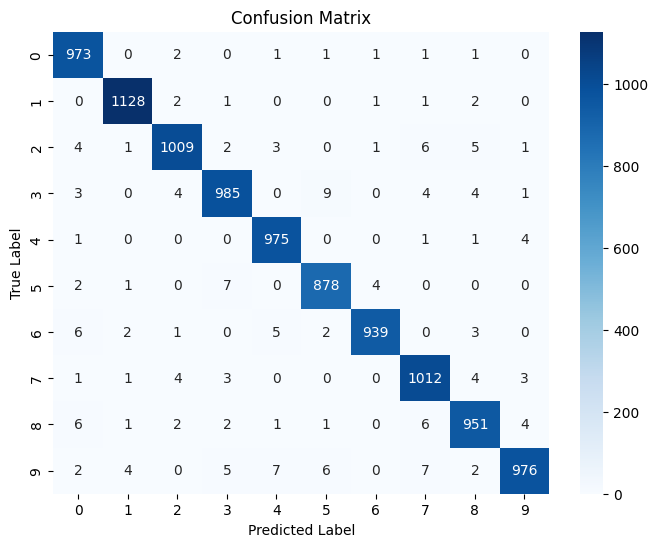

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# y_true: Ground truth (correct) target values
# y_pred: Estimated targets as returned by a classifier
y_pred = model.predict(X_valid)
cm = confusion_matrix(y_valid, np.argmax(y_pred, axis = 1))
# Plotting the confusion matrix (recommended for better visualization)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Data loading and pre-processing (PyTorch)

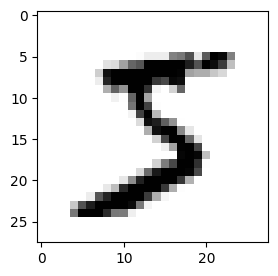

In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

training_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = transforms.ToTensor() #automatically divides by 255
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    download = True,
    transform = transforms.ToTensor()
)

img, label = training_data[0]
plt.figure(1, figsize=(3, 3))
plt.imshow(img.squeeze(), cmap=plt.cm.gray_r)
plt.show()

In [16]:
batch_size = 512
#create data loaders
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

## Buinding a CNN with PyTorch

In [38]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
class classifier(nn.Module):
  def __init__(self):
    super(classifier, self).__init__()
    self.conv0 = nn.Conv2d(1, 32, 3, stride = 1, padding = 'same')
    # He initialization (for ReLU)
    nn.init.kaiming_normal_(self.conv0.weight)
    nn.init.constant_(self.conv0.bias, 0)

    #self.pool = nn.MaxPool2d(2,2)
    self.dr = nn.Dropout(0.15)

    self.fl = nn.Flatten()

    self.lin0 = nn.Linear(32*28*28, 32)
    # He initialization (for ReLU)
    nn.init.kaiming_normal_(self.lin0.weight)
    nn.init.constant_(self.lin0.bias, 0)

    self.out = nn.Linear(32, 10)
    #Xavie (for the output layer )
    nn.init.xavier_normal_(self.out.weight)
    nn.init.constant_(self.out.bias, 0)

  def forward(self, x):
    x = F.relu(self.conv0(x))
    #x = self.pool(x)
    x = self.dr(x)
    x = self.fl(x)
    x = F.relu(self.lin0(x))
    x = self.out(x)
    return x



In [57]:
def train_one_epoch(epoch_index, tb_writer):
  running_loss = 0
  last_loss = 0
  correct = 0
  total = 0
  for i, data in enumerate(train_dataloader):
    inputs, labels = data

    optimizer.zero_grad()

    outputs = PyTorchmodel(inputs)

    loss = loss_fn(outputs, labels)
    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    preds = outputs.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

    log_interval = len(train_dataloader) // 5   # ~5 logs per epoch

    if (i + 1) % log_interval == 0:
        train_accuracy = correct / total
        last_loss = running_loss / log_interval
        print('  batch {} loss: {} accuracy: {}'.format(i + 1, last_loss,train_accuracy ))

        tb_x = epoch_index * len(train_dataloader) + i + 1
        tb_writer.add_scalar('Loss/train', last_loss, tb_x)

        running_loss = 0.

  return last_loss, train_accuracy




In [60]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

PyTorchmodel = classifier()
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(PyTorchmodel.parameters())


# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 10

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    PyTorchmodel.train(True)
    avg_loss, avg_accuracy = train_one_epoch(epoch_number, writer)

    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    PyTorchmodel.eval()

    correct = 0
    total = 0
    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():

        for i, vdata in enumerate(test_dataloader):
            vinputs, vlabels = vdata
            voutputs = PyTorchmodel(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

            #adding accurcay calculations
            preds = voutputs.argmax(dim = 1)
            correct +=(preds == vlabels).sum().item()
            total += vlabels.size(0)

    avg_vloss = running_vloss / (i + 1)
    val_accuracy = correct/total
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    print('ACCURACY train {} valid {}'.format(avg_accuracy, val_accuracy))

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'PyTorchmodel_{}_{}'.format(timestamp, epoch_number)
        torch.save(PyTorchmodel.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 23 loss: 0.6978839545146279 accuracy: 0.78515625
  batch 46 loss: 0.31078271179095557 accuracy: 0.8477411684782609
  batch 69 loss: 0.24223506385865418 accuracy: 0.8748867753623188
  batch 92 loss: 0.20845408024995224 accuracy: 0.8903277853260869
  batch 115 loss: 0.16302703061829443 accuracy: 0.9029551630434782
LOSS train 0.16302703061829443 valid 0.14424028992652893
ACCURACY train 0.9029551630434782 valid 0.9567
EPOCH 2:
  batch 23 loss: 0.1349518545295881 accuracy: 0.9610224184782609
  batch 46 loss: 0.12242727823879408 accuracy: 0.9631029211956522
  batch 69 loss: 0.11158328406188799 accuracy: 0.9645323822463768
  batch 92 loss: 0.10640023098043773 accuracy: 0.9656717051630435
  batch 115 loss: 0.09134451380890349 accuracy: 0.9674592391304347
LOSS train 0.09134451380890349 valid 0.0919852927327156
ACCURACY train 0.9674592391304347 valid 0.9725
EPOCH 3:
  batch 23 loss: 0.0800153272955314 accuracy: 0.9777513586956522
  batch 46 loss: 0.0724429888245852 accuracy: 0.9

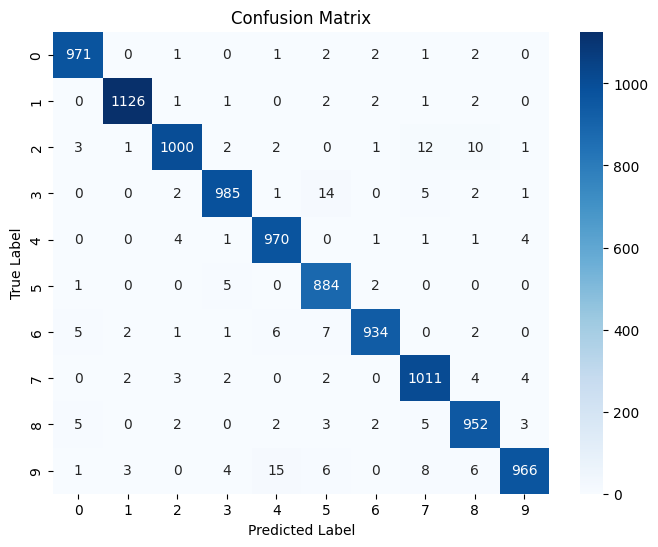

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

PyTorchmodel.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_dataloader:   # or valid_dataloader if you have one
        outputs = PyTorchmodel(inputs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()